<h3>Importing neccessary package</h3>

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h3> importing the file</h3>

In [70]:
df = pd.read_csv("../data/raw/loan.csv")
df.head()

/tmp/ipykernel_734974/1708148095.py:1: DtypeWarning: Columns (0: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/loan.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


<h3>checking the shape, data types, and number of null values </h3>

In [71]:
# df.shape
df.dtypes
# # df.head()
# df.isnull().sum().sort_values(ascending=False)

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
                               ...   
tax_liens                     float64
tot_hi_cred_lim               float64
total_bal_ex_mort             float64
total_bc_limit                float64
total_il_high_credit_limit    float64
Length: 111, dtype: object

<h3>Identified and dropped 100%-empty columns</h3>

In [72]:

fully_empty = df.columns[df.isnull().sum() == len(df)]
# print(fully_empty)
df = df.drop(columns=fully_empty)
print(df.shape)

(39717, 57)


In [73]:
missing_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_values[missing_values > 0])

next_pymnt_d                  97.129693
mths_since_last_record        92.985372
mths_since_last_delinq        64.662487
desc                          32.585543
emp_title                      6.191303
emp_length                     2.706650
pub_rec_bankruptcies           1.754916
last_pymnt_d                   0.178765
collections_12_mths_ex_med     0.140998
chargeoff_within_12_mths       0.140998
revol_util                     0.125891
tax_liens                      0.098195
title                          0.027696
last_credit_pull_d             0.005036
dtype: float64


<h3>Data Dropped low-value text columns (desc, emp_title, title)</h3>

In [74]:
df.drop(columns=['desc', 'emp_title', 'title'], inplace=True)
print(df.shape)

(39717, 54)


<h3>Dropped >50% missing columns</h3>

In [75]:
missing_pct = (df.isnull().sum() / len(df) * 100)
print(missing_pct[missing_pct > 0])
df.drop(columns=missing_values[missing_values > 50].index, inplace=True)
print(df.shape)


emp_length                     2.706650
mths_since_last_delinq        64.662487
mths_since_last_record        92.985372
revol_util                     0.125891
last_pymnt_d                   0.178765
next_pymnt_d                  97.129693
last_credit_pull_d             0.005036
collections_12_mths_ex_med     0.140998
chargeoff_within_12_mths       0.140998
pub_rec_bankruptcies           1.754916
tax_liens                      0.098195
dtype: float64
(39717, 51)


<h3> Fixed a string-formatted percentage column (revol_util) - Imputed remaining small gaps (mode for categorical, median/0 for numeric) - Dropped rows with negligible remaining missingness</h3>

In [76]:
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].mode()[0])
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df.dropna(subset = ['last_pymnt_d', 'collections_12_mths_ex_med', 
                   'chargeoff_within_12_mths', 'tax_liens', 'last_credit_pull_d'], inplace=True)
print(df.shape)
print(df.isnull().sum().sum())

(39588, 51)
0


In [77]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid     32899
Charged Off     5549
Current         1140
Name: count, dtype: int64


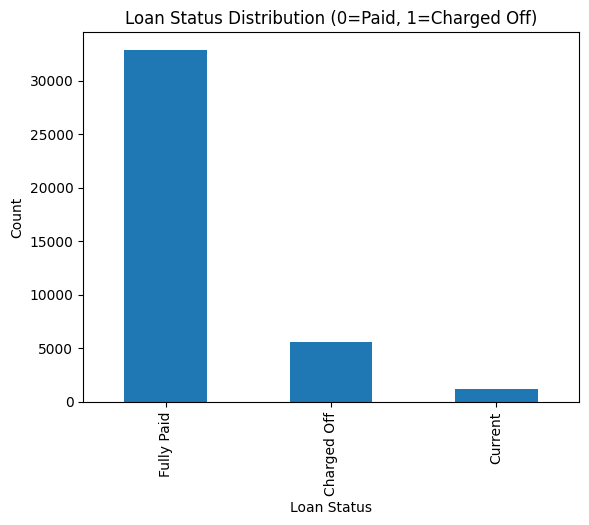

In [78]:
df['loan_status'].value_counts().plot(kind='bar')
plt.title('Loan Status Distribution (0=Paid, 1=Charged Off)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

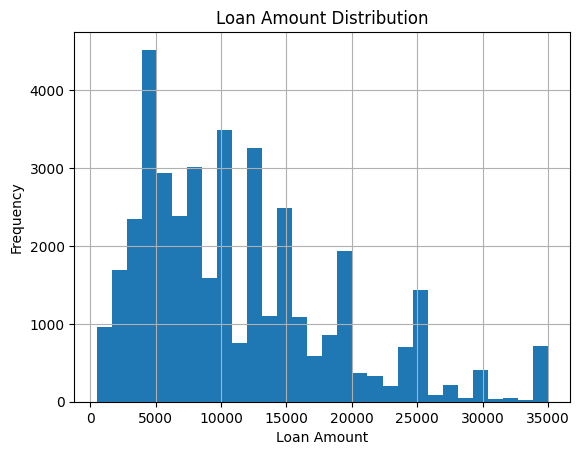

In [79]:
df['loan_amnt'].hist(bins=30)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

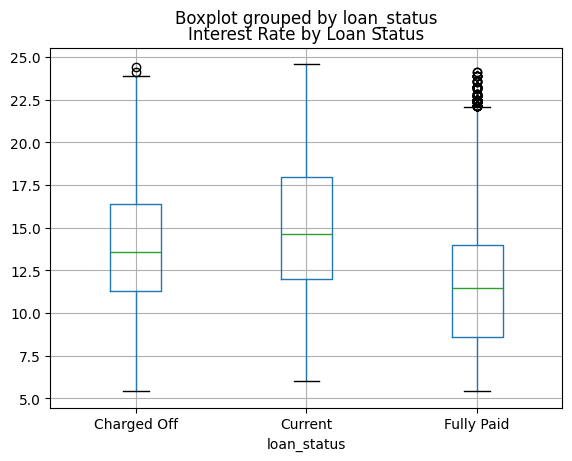

In [80]:
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)
df.boxplot(column='int_rate', by='loan_status')
plt.title('Interest Rate by Loan Status')
plt.show()



In [ ]:
<h3>Create portfolio targets and summarize loan outcomes</h3>
</VSCode.Cell>
<VSCode.Cell language="python">
# create a clean binary default target and an economic realized return target
default_states = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off"]
df['loan_status_clean'] = df['loan_status'].astype(str).str.strip()
df['is_default'] = df['loan_status_clean'].isin(default_states).astype(int)
df['is_completed'] = df['loan_status_clean'].isin(['Fully Paid', 'Charged Off', 'Default']).astype(int)

df['funded_amnt_inv'] = pd.to_numeric(df['funded_amnt_inv'], errors='coerce')
df['total_pymnt_inv'] = pd.to_numeric(df['total_pymnt_inv'], errors='coerce')
df['realized_return'] = (df['total_pymnt_inv'] - df['funded_amnt_inv']) / df['funded_amnt_inv']
df.loc[df['funded_amnt_inv'] <= 0, 'realized_return'] = pd.NA

df['censored'] = (~df['is_completed']).astype(int)

print('Loan status counts:')
print(df['loan_status_clean'].value_counts())
print('\nCompleted loans:', int(df['is_completed'].sum()))
print('Censored loans: {:.2%}'.format(df['censored'].mean()))
print('Default rate among completed loans: {:.2%}'.format(df.loc[df['is_completed'], 'is_default'].mean()))

completed = df.loc[df['is_completed']].copy()
print('\nRealized return summary for completed loans:')
print(completed['realized_return'].describe())

print('\nAverage interest rate by loan status:')
print(df.groupby('loan_status_clean')['int_rate'].mean().sort_values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
completed['realized_return'].hist(bins=40, ax=axes[0])
axes[0].set_title('Realized Return Distribution (Completed Loans)')
axes[0].set_xlabel('Realized Return')
axes[0].set_ylabel('Count')

df['loan_status_clean'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Loan Status Counts')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()
